## Chapter 8 - Applied

### Question 7

In [707]:
# Imports
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data , confusion_table
from ISLP.models import ModelSpec as MS

# New imports
from sklearn.tree import (
    DecisionTreeClassifier as DTC,
    DecisionTreeRegressor as DTR,
    plot_tree,
    export_text
)
from sklearn.metrics import (
    accuracy_score,
    log_loss
)
from sklearn.ensemble import (
    RandomForestRegressor as RF,
    GradientBoostingRegressor as GBR
)
from ISLP.bart import BART

# My imports
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.naive_bayes import GaussianNB
import seaborn as sns

In [2]:
# Load boston dataset
boston = pd.read_csv('data/Boston.csv')

# Quick info
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [3]:
# Check initial observations
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [4]:
# Drop first columns
boston = boston.iloc[:, 1:]

In [5]:
# Get feature names
feature_names = boston.columns.drop('medv')

# Transform dataset into an array
X = np.array(boston.drop(columns='medv'))

# Get y
y = boston['medv']

In [6]:
# Split the dataset
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [ ]:
# Number of trees - 1 to 500
n_trees = np.arange(1, 501, 10)

# Initialize test MSE matrix/dataframe
mse_test_df = pd.DataFrame(columns=['m=p', 'm=p/2', 'm=sqrt(p)'])

# Number of features
p = len(feature_names)

# Parameter to test m=p (bagging)
m1 = p
# Parameter to test m=p/2
m2 = int(p/2)
# Parameteer to test m=sqrt(p)
m3 = int(np.sqrt(p))

# Loop through the number of trees
for n in n_trees:

    # Create & fit RF for m1
    random_forest_m1 = RF(
        n_estimators=n,
        max_features=m1,
        random_state=0
    ).fit(X_train, y_train)

    # Create & fit RF for m2
    random_forest_m2 = RF(
        n_estimators=n,
        max_features=m2,
        random_state=0
    ).fit(X_train, y_train)

    # Create & fit RF for m3
    random_forest_m3 = RF(
        n_estimators=n,
        max_features=m3,
        random_state=0
    ).fit(X_train, y_train)

    # Use the models for test prediction
    y_hat_m1 = random_forest_m1.predict(X_test)
    y_hat_m2 = random_forest_m2.predict(X_test)
    y_hat_m3 = random_forest_m3.predict(X_test)

    # Compute test MSE
    mse_test_m1 = np.mean((y_test - y_hat_m1)**2)
    mse_test_m2 = np.mean((y_test - y_hat_m2)**2)
    mse_test_m3 = np.mean((y_test - y_hat_m3)**2)

    # Update the dataframe
    mse_test_df.loc[len(mse_test_df)] = mse_test_m1, mse_test_m2, mse_test_m3

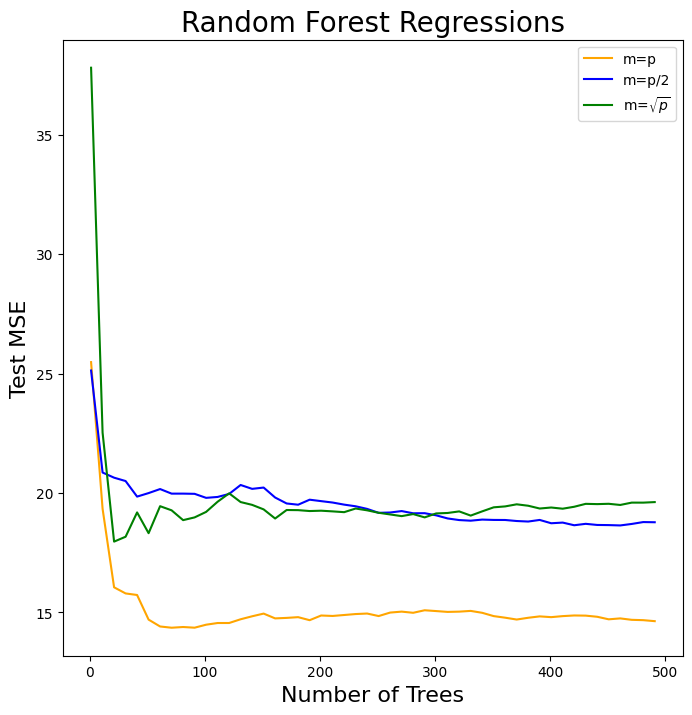

In [8]:
# Get x values/ticks for the plot
plot_idx = np.arange(1, 501, 10)

# Create ax
ax = subplots(figsize=(8,8))[1]

# Plot test errors
ax.plot(plot_idx, mse_test_df.iloc[:, 0], c='orange', label='m=p')
ax.plot(plot_idx, mse_test_df.iloc[:, 1], c='b', label='m=p/2')
ax.plot(plot_idx, mse_test_df.iloc[:, 2], c='g', label=r'm=$\sqrt{p}$')

# Set titles
ax.set_xlabel('Number of Trees', fontsize=16)
ax.set_ylabel('Test MSE', fontsize=16)
ax.set_title('Random Forest Regressions', fontsize=20)

# Set legend
ax.legend();

Our results reinforce the findings from the lab section on the same dataset. The bagging method outperforms the random forest when using the standard number of features, $m=\sqrt(p)$, as well as when using $m=p/2$. Additionally, we observe that increasing the number of trees beyond 100 provides no improvement in performance.

---

### Question 8

#### 8a)

In [9]:
# Load the data
carseats = pd.read_csv('data/Carseats.csv')

# Adapt column names
carseats.columns = [x.lower() for x in carseats.columns]

# Quick info
carseats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sales        400 non-null    float64
 1   compprice    400 non-null    int64  
 2   income       400 non-null    int64  
 3   advertising  400 non-null    int64  
 4   population   400 non-null    int64  
 5   price        400 non-null    int64  
 6   shelveloc    400 non-null    object 
 7   age          400 non-null    int64  
 8   education    400 non-null    int64  
 9   urban        400 non-null    object 
 10  us           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [10]:
# Check initial observations
carseats.head()

,sales,compprice,income,advertising,population,price,shelveloc,age,education,urban,us
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [11]:
# Adapt the dataset to comtemplate dummies
X = pd.get_dummies(
    carseats.drop(columns='sales'),
    drop_first=True,
    dtype='int'
)

# Quick info
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   compprice         400 non-null    int64
 1   income            400 non-null    int64
 2   advertising       400 non-null    int64
 3   population        400 non-null    int64
 4   price             400 non-null    int64
 5   age               400 non-null    int64
 6   education         400 non-null    int64
 7   shelveloc_Good    400 non-null    int64
 8   shelveloc_Medium  400 non-null    int64
 9   urban_Yes         400 non-null    int64
 10  us_Yes            400 non-null    int64
dtypes: int64(11)
memory usage: 34.5 KB


In [12]:
# Look at the initial observations
X.head()

,compprice,income,advertising,population,price,age,education,shelveloc_Good,shelveloc_Medium,urban_Yes,us_Yes
0,138,73,11,276,120,42,17,0,0,1,1
1,111,48,16,260,83,65,10,1,0,1,1
2,113,35,10,269,80,59,12,0,1,1,1
3,117,100,4,466,97,55,14,0,1,1,1
4,141,64,3,340,128,38,13,0,0,1,0


In [13]:
# Get feature names
feature_names = X.columns

# Transform the dataset into an array
X = np.asarray(X)

# Get y
y = np.asarray(carseats['sales'])

# Split the dataset into training & test set
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, test_size=0.3, random_state=0
)

#### 8b)

In [14]:
# Set up & fit the regression tree
regression_tree = DTR().fit(X_train, y_train)

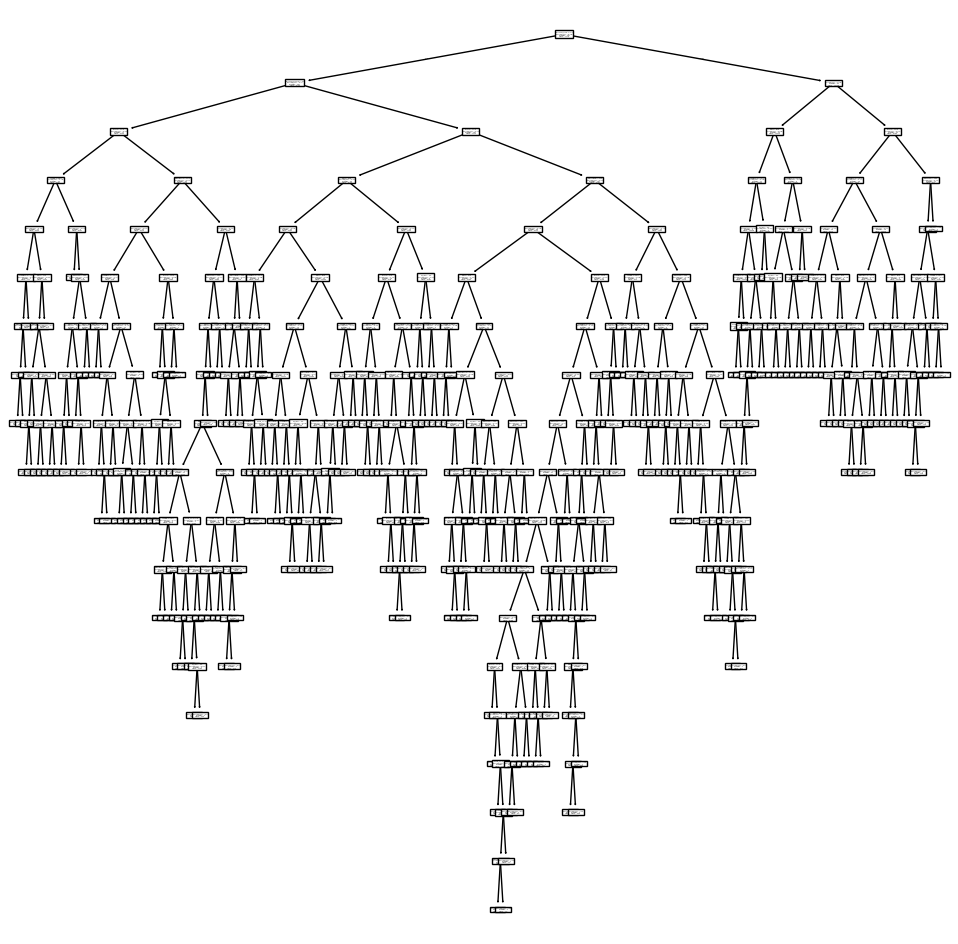

In [15]:
# Plot the tree
ax = subplots(figsize=(12,12))[1]
plot_tree(regression_tree, feature_names=feature_names, ax=ax);

In [16]:
# Predict & compute test MSE
y_hat = regression_tree.predict(X_test)
mse_test = np.mean((y_test - y_hat)**2)
round(mse_test, 4)

4.6747

In [17]:
# Square root of MSE
rmse_test = np.sqrt(mse_test)
round(rmse_test, 4)

2.1621

In [18]:
# Get the mean of y_test
y_test_mean = y_test.mean()
round(y_test_mean, 4)

7.7717

In [19]:
# Compute the percentage of error (p.87)
error_perc = rmse_test / y_test_mean
round(error_perc, 4)

0.2782

Our model achieves an MSE of approximately 5.0242, resulting in an RMSE of about 2.2415. Given that the mean value of $y_{test}$ is around 7.77, this corresponds to a percentage error of 28.84%. 

An RMSE of 2.2415 suggests that, on average, the model's test predictions deviate from the true median sales value by roughly 2.24 units.

#### 8c)

In [20]:
# Get the cost complexity pruning path
ccp_path = regression_tree.cost_complexity_pruning_path(X_train, y_train)

# Set up a k-fold method
kfold = skm.KFold(10, random_state=0, shuffle=True)

# Set up a grid search cross-validation method
grid = skm.GridSearchCV(
    regression_tree,
    {'ccp_alpha': ccp_path.ccp_alphas},
    refit=True,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

# Perform/fit the grid search
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=DecisionTreeRegressor(),
             param_grid={'ccp_alpha': array([0.00000000e+00, 1.01506105e-16, 1.78571428e-07, 1.78571428e-07,
       1.78571429e-07, 1.78571429e-07, 1.78571429e-07, 7.14285714e-07,
       7.14285714e-07, 7.14285714e-07, 1.60714286e-06, 1.60714286e-06,
       1.60714286e-06, 2.85714286e-06, 2.85714286e-...
       6.62700000e-02, 7.00808066e-02, 7.90021684e-02, 8.05497781e-02,
       8.47550327e-02, 8.49455357e-02, 8.66453720e-02, 9.03804241e-02,
       9.54786602e-02, 9.62583335e-02, 1.14091364e-01, 1.17401481e-01,
       1.20555171e-01, 1.49808730e-01, 1.73961027e-01, 2.19278404e-01,
       2.24440270e-01, 2.52100424e-01, 2.78062546e-01, 5.22532970e-01,
       5.38486128e-01, 8.83592578e-01, 1.90014702e+00])},
             scoring='neg_mean_squared_error')

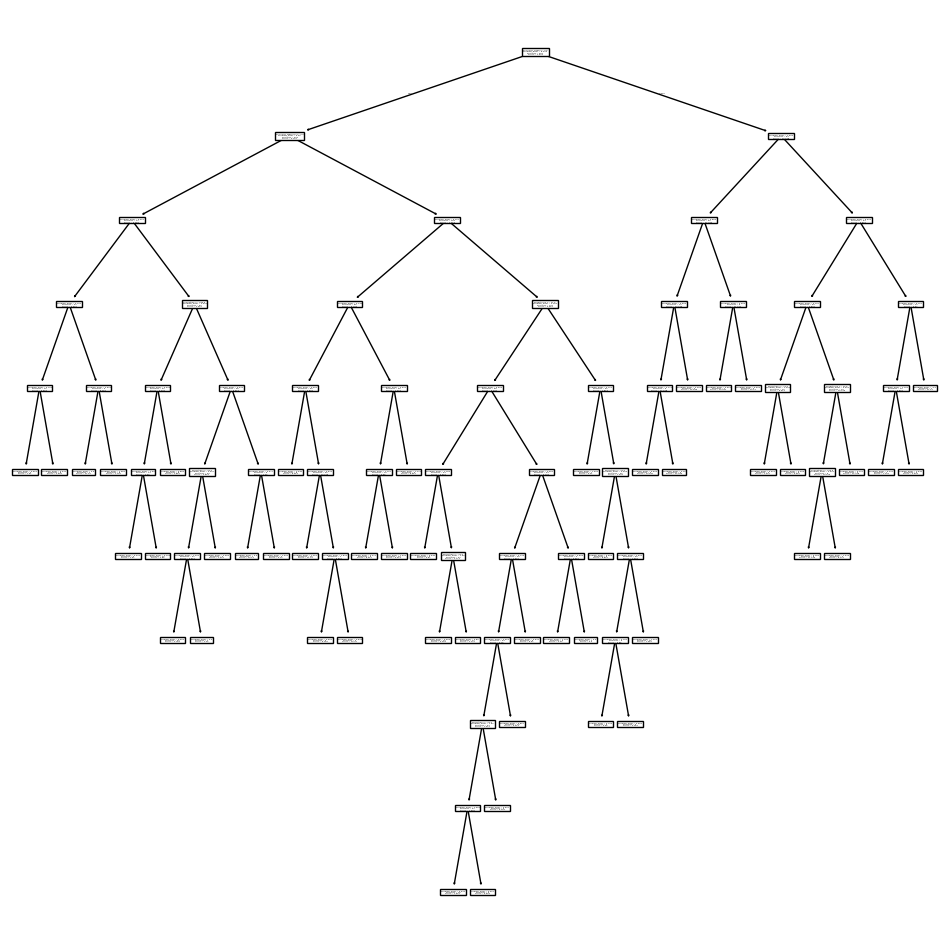

In [21]:
# Plot the tree
ax = subplots(figsize=(12,12))[1]
plot_tree(grid.best_estimator_, feature_names=feature_names, ax=ax);

In [22]:
# Predict & compute test MSE
y_hat = grid.best_estimator_.predict(X_test)
mse_test = np.mean((y_test - y_hat)**2)
round(mse_test, 4)

4.6992

After pruning the regression tree, the test MSE decreases to 4.2524, representing an improvement over the initial MSE of 5.0242. This indicates that pruning enhances the model's generalization by mitigating overfitting.

Additionally, the pruned tree is significantly smaller and less complex, making it more interpretable while improving accuracy.

#### 8d)

In [23]:
# Bagging features is m=p
m = len(feature_names)

# Set up a bagging method
bagging = RF(
    n_estimators=100,
    max_features=m,
    random_state=0
)

# Fit
bagging.fit(X_train, y_train)

RandomForestRegressor(max_features=11, random_state=0)

In [24]:
# Predict & compute test MSE
y_hat = bagging.predict(X_test)
mse_test = np.mean((y_test - y_hat)**2)
round(mse_test, 4)

2.0281

In [25]:
# Create a dataframe for feature importance
feature_imp = pd.DataFrame(
    {'importance': bagging.feature_importances_},
    index=feature_names
)

# Sort & show results
feature_imp.sort_values(by='importance', ascending=False)

,importance
price,0.277294
shelveloc_Good,0.222583
age,0.107775
compprice,0.097186
shelveloc_Medium,0.082756
advertising,0.073830
income,0.053136
population,0.041544
education,0.031885
us_Yes,0.006801


Bagging yields the lowest test MSE so far, achieving a value of 2.0281. Additionally, the feature importance rankings align with expectations, with 'price' as the most influential predictor, followed by a good 'shelveloc'.

#### 8e)

In [26]:
# Set different 'm' values for random forest
m1 = p # bagging
m2 = int(p/2)
m3 = int(np.sqrt(p))

# Initialize test MSE dataframe
mse_test_df = pd.DataFrame(columns=['m=p', 'm=p/2', 'm=sqrt(p)'])

# Set up & fit random forest methods
random_forest_m1 = RF(max_features=m1, random_state=0).fit(X_train, y_train)
random_forest_m2 = RF(max_features=m2, random_state=0).fit(X_train, y_train)
random_forest_m3 = RF(max_features=m3, random_state=0).fit(X_train, y_train)

# Predict on test dataset
y_hat_m1 = random_forest_m1.predict(X_test)
y_hat_m2 = random_forest_m2.predict(X_test)
y_hat_m3 = random_forest_m3.predict(X_test)

# Compute test MSE
mse_test_m1 = np.mean((y_test - y_hat_m1)**2)
mse_test_m2 = np.mean((y_test - y_hat_m2)**2)
mse_test_m3 = np.mean((y_test - y_hat_m3)**2)

# Update dataframe
mse_test_df.loc[len(mse_test_df)] = mse_test_m1, mse_test_m2, mse_test_m3

# Show results
mse_test_df.rename(index={0: 'test MSE'})

,m=p,m=p/2,m=sqrt(p)
test MSE,2.028116,2.012088,2.454448


In [27]:
# Compute RMSE
rmse_test_m1 = np.sqrt(mse_test_m1)
rmse_test_m2 = np.sqrt(mse_test_m2)
rmse_test_m3 = np.sqrt(mse_test_m3)

# Compute the mean of y_test
y_test_mean = np.mean(y_test)

# Compute error rate
error_rate_m1 = round((rmse_test_m1 / y_test_mean) * 100, 2)
error_rate_m2 = round((rmse_test_m2 / y_test_mean) * 100, 2)
error_rate_m3 = round((rmse_test_m3 / y_test_mean) * 100, 2)

# Create & update dataframe that holds the results
error_rate_df = pd.DataFrame(columns=['m=p', 'm=p/2', 'm=sqrt(p)'])
error_rate_df.loc[len(error_rate_df)] = error_rate_m1, error_rate_m2, error_rate_m3

# Rename index & show results
error_rate_df.rename(index={0: 'test error rate'})

,m=p,m=p/2,m=sqrt(p)
test error rate,18.32,18.25,20.16


In [28]:
# Create a dataframe for feature importance
feature_imp_m1 = pd.DataFrame(
    {'importance m=p': random_forest_m1.feature_importances_},
    index=feature_names
)

# Sort & show dataframe
feature_imp_m1.sort_values(by='importance m=p', ascending=False)

,importance m=p
price,0.277294
shelveloc_Good,0.222583
age,0.107775
compprice,0.097186
shelveloc_Medium,0.082756
advertising,0.073830
income,0.053136
population,0.041544
education,0.031885
us_Yes,0.006801


In [29]:
# Create a dataframe for m2 feature importance
feature_imp_m2 = pd.DataFrame(
    {'importance m=p/2': random_forest_m2.feature_importances_},
    index=feature_names
)

# Sort & show feature importance
feature_imp_m2.sort_values(by='importance m=p/2', ascending=False)

,importance m=p/2
price,0.275431
shelveloc_Good,0.195474
age,0.110715
compprice,0.106655
advertising,0.082311
shelveloc_Medium,0.062251
income,0.060100
population,0.051105
education,0.039142
us_Yes,0.010825


In [30]:
# Create a dataframe for m3 feature importance
feature_imp_m3 = pd.DataFrame(
    {'importance m=sqrt(p)': random_forest_m3.feature_importances_},
    index=feature_names
)

# Sort & show feature importance
feature_imp_m3.sort_values(by='importance m=sqrt(p)', ascending=False)

,importance m=sqrt(p)
price,0.234740
shelveloc_Good,0.161402
age,0.122110
advertising,0.094275
compprice,0.090579
income,0.086714
population,0.075341
shelveloc_Medium,0.052910
education,0.052468
us_Yes,0.017440


Models that uses more features, $m=p$ (bagging) and $m=p/2$, demonstrate better performance compared to the standard random forest configuration, which selects $m=\sqrt(p)$.

Despite the difference, all 3 models achieve relatively similar test performance, with $m=p$ and $m=p/2$ delivering the best results. Even the model with the worse performance is not significantly worse. This is further supported by the feature importance rankings, where all 3 models indentify the same top 3 most influential features.

The key distinction between the models is how the top-performing models assign greate weight to the 2 most relevant features, reinforcing their dominance in the prediction.

#### 8f)

In [31]:
# Create & fit BART model
bart = BART(random_state=0, burnin=5, ndraw=15).fit(X_train, y_train)

In [32]:
# Predict & compute test MSE
y_hat = bart.predict(X_test)
mse_test = np.mean((y_test - y_hat)**2)
np.round(mse_test, 4)

1.709

In [33]:
# Check how many times a feature appear in the tree collection
feature_inclusion = pd.Series(bart.variable_inclusion_.mean(0), index=feature_names)
feature_inclusion

compprice           31.200000
income              23.466667
advertising         26.333333
population          22.466667
price               36.066667
age                 24.400000
education           24.400000
shelveloc_Good      32.866667
shelveloc_Medium    27.200000
urban_Yes           23.200000
us_Yes              28.133333
dtype: float64

BART achievest the best performance among all models, with a test MSE of 1.709. The feature importance in BART differs significantly from that of the random forest models. This discrepancy suggests that the feature importance rankings observed in the random forest models may not be entirely reliable.

---

### Question 9

#### 9a)

In [34]:
# Load OJ dataset
oj = pd.read_csv('data/OJ.csv')

# Adapt column names
oj.columns = [x.lower() for x in oj.columns]

# Quick dataset info
oj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   purchase        1070 non-null   object 
 1   weekofpurchase  1070 non-null   int64  
 2   storeid         1070 non-null   int64  
 3   pricech         1070 non-null   float64
 4   pricemm         1070 non-null   float64
 5   discch          1070 non-null   float64
 6   discmm          1070 non-null   float64
 7   specialch       1070 non-null   int64  
 8   specialmm       1070 non-null   int64  
 9   loyalch         1070 non-null   float64
 10  salepricemm     1070 non-null   float64
 11  salepricech     1070 non-null   float64
 12  pricediff       1070 non-null   float64
 13  store7          1070 non-null   object 
 14  pctdiscmm       1070 non-null   float64
 15  pctdiscch       1070 non-null   float64
 16  listpricediff   1070 non-null   float64
 17  store           1070 non-null   i

In [35]:
# Check first observations
oj.head()

,purchase,weekofpurchase,storeid,pricech,pricemm,discch,discmm,specialch,specialmm,loyalch,salepricemm,salepricech,pricediff,store7,pctdiscmm,pctdiscch,listpricediff,store
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [36]:
# Get the response/endogenous variable 
y = oj['purchase'].astype('category')

# Get the features
X = pd.get_dummies(oj.drop(columns='purchase'), drop_first=True, dtype='int')

# Get feature names
feature_names = X.columns

# Transform the dataset into an array
X = np.asarray(X)

In [37]:
# Split the dataset
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, train_size=800, random_state=0
)

#### 9b)

In [38]:
# Set up & fit a tree model
tree_gini = DTC(criterion='gini', random_state=0).fit(X_train, y_train)
tree_log_loss = DTC(criterion='log_loss', random_state=0).fit(X_train, y_train)

#### 9c)

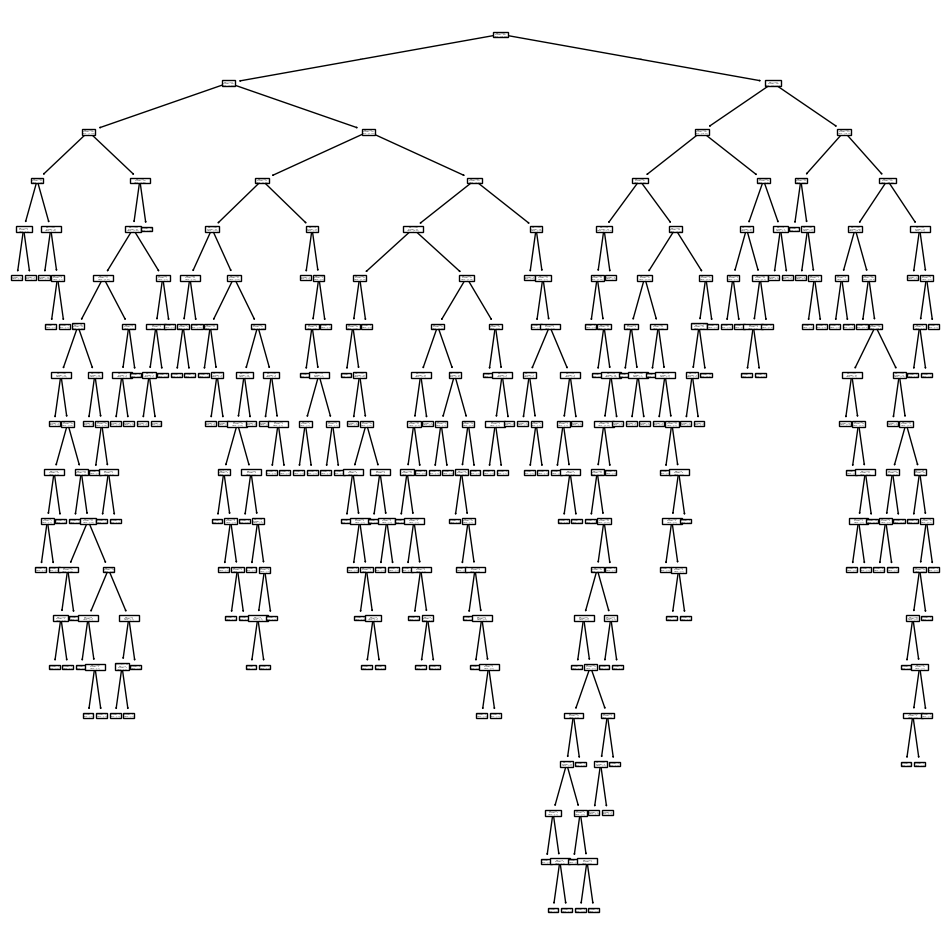

In [39]:
# Plot gini tree
ax = subplots(figsize=(12,12))[1]
plot_tree(tree_gini, feature_names=feature_names, ax=ax);

In [40]:
# Count the leaves (final nodes)
tree_gini_leaves = tree_gini.tree_.n_leaves
tree_log_loss_leaves = tree_log_loss.tree_.n_leaves

# Print leaves (final nodes) info
print(f"""
tree_gini_leaves:    \t{tree_gini_leaves}
tree_log_loss_leaves:\t{tree_log_loss_leaves}
""")


tree_gini_leaves:    	165
tree_log_loss_leaves:	169



The number of leaves in the trees, along with the gini tree plot, indicates that we have large and complex trees, consisting of over 160 terminal nodes. This could suggest potential overfitting, with the model capturing noise rather than meaningful patterns in the data.

#### 9d)

In [41]:
# Show the text summary of the tree
print(export_text(tree_gini, feature_names=feature_names, show_weights=True))

|--- loyalch <= 0.51
|   |--- loyalch <= 0.28
|   |   |--- loyalch <= 0.06
|   |   |   |--- storeid <= 1.50
|   |   |   |   |--- pctdiscmm <= 0.18
|   |   |   |   |   |--- weights: [1.00, 0.00] class: CH
|   |   |   |   |--- pctdiscmm >  0.18
|   |   |   |   |   |--- weights: [0.00, 2.00] class: MM
|   |   |   |--- storeid >  1.50
|   |   |   |   |--- weekofpurchase <= 268.50
|   |   |   |   |   |--- weights: [0.00, 49.00] class: MM
|   |   |   |   |--- weekofpurchase >  268.50
|   |   |   |   |   |--- loyalch <= 0.00
|   |   |   |   |   |   |--- weights: [0.00, 7.00] class: MM
|   |   |   |   |   |--- loyalch >  0.00
|   |   |   |   |   |   |--- weights: [1.00, 0.00] class: CH
|   |   |--- loyalch >  0.06
|   |   |   |--- weekofpurchase <= 273.50
|   |   |   |   |--- salepricech <= 1.94
|   |   |   |   |   |--- weekofpurchase <= 263.50
|   |   |   |   |   |   |--- store <= 1.50
|   |   |   |   |   |   |   |--- weekofpurchase <= 228.00
|   |   |   |   |   |   |   |   |--- weights: [1.0

By setting show_weights=True, we can observe the number of observations in each leaf that determine the final classification.

At deeper terminal nodes, it is common to see splits where only a single observation falls into each class. For instance, one final node splits based on a threshold value of 0.15 for 'loyalch'. In this case, there is only one observation with a value less than or equal to 0.15, which is classified as 'CH', and one observation with a value greater than 0.15, which is classified as 'MM'. This highlights the model's tendency to create highly specific splits, which may lead to overfitting.

#### 9e)

In [42]:
# Prediction on train dataset
y_hat_train_gini = tree_gini.predict(X_train)
y_hat_train_log_loss = tree_log_loss.predict(X_train)

# Predict on test dataset
y_hat_test_gini = tree_gini.predict(X_test)
y_hat_test_log_loss = tree_log_loss.predict(X_test)

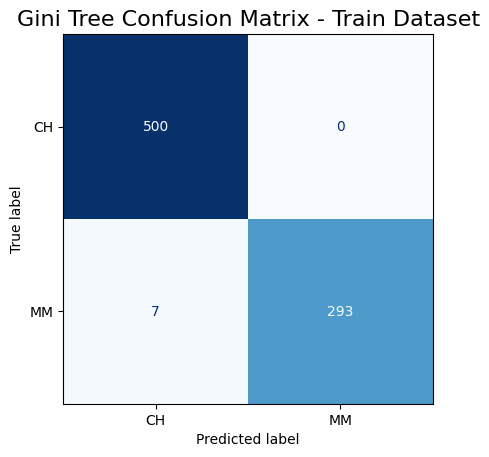

In [43]:
# Plot CM of gini tree on train dataset
ConfusionMatrixDisplay.from_estimator(
    tree_gini,
    X_train,
    y_train,
    cmap='Blues',
    colorbar=False
)
# Add title
plt.title('Gini Tree Confusion Matrix - Train Dataset', fontsize=16);

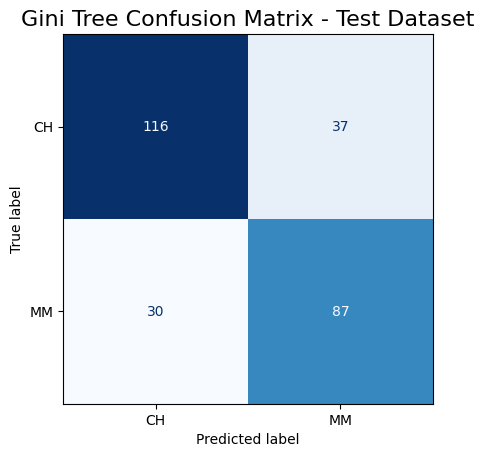

In [44]:
# Plot CM of gini tree on test dataset
ConfusionMatrixDisplay.from_estimator(
    tree_gini,
    X_test,
    y_test,
    cmap='Blues',
    colorbar=False
)
# Add title
plt.title('Gini Tree Confusion Matrix - Test Dataset', fontsize=16);

In [45]:
# Get train accuracy
accuracy_train_gini = accuracy_score(y_train, y_hat_train_gini)
accuracy_train_log_loss = accuracy_score(y_train, y_hat_train_log_loss)
                                     
# Get test accuracy
accuracy_test_gini = accuracy_score(y_test, y_hat_test_gini)
accuracy_test_log_loss = accuracy_score(y_test, y_hat_test_log_loss)

# Print information
print(f"""
accuracy_train_gini:    \t{round(accuracy_train_gini * 100, 2)}
accuracy_train_log_loss:\t{round(accuracy_train_log_loss * 100, 2)}

accuracy_test_gini:     \t{round(accuracy_test_gini * 100, 2)}
accuracy_test_log_loss: \t{round(accuracy_test_log_loss * 100, 2)}
""")


accuracy_train_gini:    	99.12
accuracy_train_log_loss:	99.12

accuracy_test_gini:     	75.19
accuracy_test_log_loss: 	78.52



In [46]:
# Explicit error rate
round(1 - accuracy_test_log_loss, 4) * 100

21.48

Both trees, each using a different splitting criterion, have clear signs of overfitting. They achieve high accuracy on the training dataset but perform much worse on the test dataset.

We get a test error rate of 21.48% on the test dataset using a classification tree with log loss criterion.

#### 9f)

The question asks to determine optimal tree size but without providing further details on what that exactly means. We could experiment with the parameters 'max_depth' and 'max_leaf_nodes', or a combination of both, to identify the optimal tree size.

In [47]:
# Initialize a dataframe to hold the results
results = pd.DataFrame(columns=['max_leaf', 'error_rate_train', 'error_rate_cv'])

# Set up k-fold method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Loop Through a range of leaf nodes
for max_leaf_nodes in range(2, 100):

    # Set up & fit the random forest method
    tree_ = DTC(
        criterion='log_loss', 
        random_state=0, 
        max_leaf_nodes=max_leaf_nodes
    ).fit(X_train, y_train)

    # Predict on train dataset
    y_hat_train = tree_.predict(X_train)
    
    # Get accuracy & error rate
    acc_train = accuracy_score(y_train, y_hat_train)
    error_rate_train = 1 - acc_train

    # Initialize 
    acc_cv_list = []

    # Cross-validation loop
    for train_idx, val_idx in kfold.split(X_train):

        # Get the data splits
        X_train_, X_val_ = X_train[train_idx], X_train[val_idx]
        y_train_, y_val_ = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Create & fit a tree on cv data
        tree_cv = DTC(
            criterion='log_loss',
            random_state=0,
            max_leaf_nodes=max_leaf_nodes
        ).fit(X_train_, y_train_)

        # Predict
        y_hat_ = tree_cv.predict(X_val_)

        # Get accuracy & update list
        acc_fold = accuracy_score(y_val_, y_hat_)
        acc_cv_list.append(acc_fold)

    # Compute cross-validation
    acc_cv = np.mean(acc_cv_list)
    error_rate_cv = 1 - acc_cv

    # Update dataframe
    results.loc[len(results)] = max_leaf_nodes, error_rate_train, error_rate_cv

In [48]:
# Show the best cv error rate
results.iloc[results['error_rate_cv'].argmin()]

max_leaf            8.00000
error_rate_train    0.17750
error_rate_cv       0.19125
Name: 6, dtype: float64

The optimal tree size has 8 leaves and provides a cross-validation error rate of 19.125%.

#### 9g)

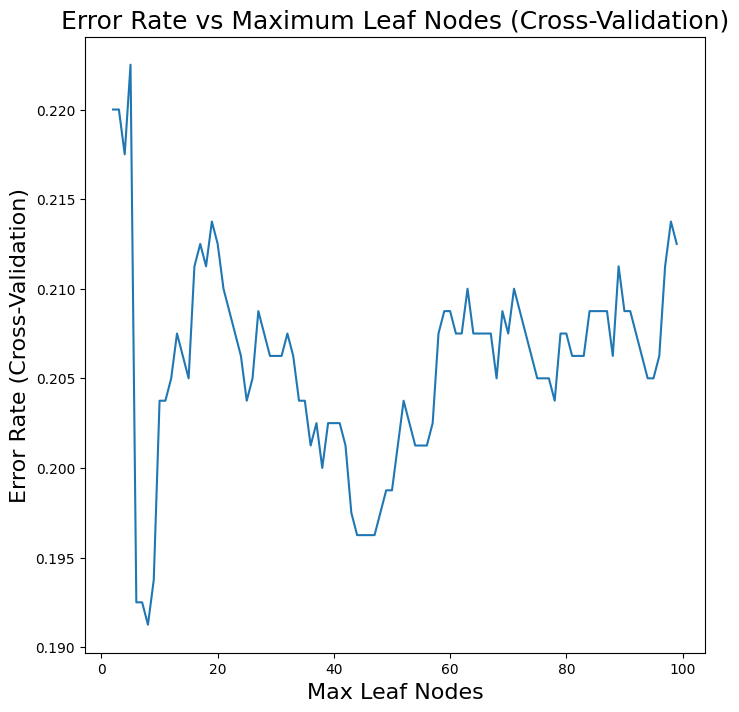

In [49]:
# Plot the results
plt.figure(figsize=(8,8))
plt.plot(results['max_leaf'], results['error_rate_cv'])

# Customize
plt.title('Error Rate vs Maximum Leaf Nodes (Cross-Validation)', fontsize=18)
plt.xlabel('Max Leaf Nodes', fontsize=16)
plt.ylabel('Error Rate (Cross-Validation)', fontsize=16);

#### 9h)

The optimal tree size has 8 terminal nodes.

#### 9i)

In [50]:
# Get the cost complexity pruning path
ccp_path = tree_log_loss.cost_complexity_pruning_path(X_train, y_train)

# Set up a k-fold method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Create a tree
tree_ = DTC(criterion='log_loss', random_state=0)

# Set up a grid method
grid = skm.GridSearchCV(
    estimator=tree_,
    param_grid={'ccp_alpha': ccp_path.ccp_alphas},
    scoring='accuracy',
    refit=True,
    cv=kfold,
)

# Fit/perform the grid search
grid.fit(X_train, y_train)   

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=DecisionTreeClassifier(criterion='log_loss',
                                              random_state=0),
             param_grid={'ccp_alpha': array([0.        , 0.00094361, 0.00094361, 0.00094361, 0.00106844,
       0.00114787, 0.00122556, 0.00135213, 0.00150402, 0.00155639,
       0.00155639, 0.00201205, 0.00201205, 0.00202281, 0.00202281,
       0.0020282 , 0.0020282 , 0.0020282...
       0.00348636, 0.00354843, 0.00380598, 0.00389142, 0.00392806,
       0.0040083 , 0.00405639, 0.00411875, 0.00426499, 0.00448109,
       0.00456436, 0.00456436, 0.00465469, 0.00465992, 0.00475013,
       0.00508762, 0.00514249, 0.00534987, 0.00536254, 0.00559983,
       0.00584974, 0.00590534, 0.0060732 , 0.00650472, 0.00659581,
       0.00692612, 0.00847498, 0.00899312, 0.00963416, 0.02303902,
       0.03271777, 0.03344416, 0.04577961, 0.26681033])},
             scoring='accuracy')

In [51]:
# Get the number of terminal nodes
print(f"""
n_leaves: {grid.best_estimator_.tree_.n_leaves}
""")


n_leaves: 8



Using k-fold cross-valiadtion to prune our classification decision tree resulted in an optimal tree with 8 terminal nodes. This the same result identified when performing k-fold cross-validation directly on the number of terminal nodes. This reinforces the reliability of choosing a tree with 8 terminal nodes.

#### 9j)

In [52]:
# Unpruned prediction & accuracy/error rate
y_hat_unpruned_train = tree_log_loss.predict(X_train)
acc_unpruned_train = accuracy_score(y_train, y_hat_unpruned_train)
error_rate_unpruned_train = round(1 - acc_unpruned_train, 4) * 100

# Pruned prediction & accuracy/error rate
y_hat_pruned_train = grid.best_estimator_.predict(X_train)
acc_pruned_train = accuracy_score(y_train, y_hat_pruned_train)
error_rate_pruned_train = round(1 - accuracy_score(y_train, y_hat_pruned_train), 4) * 100

# Print results
print(f"""
error_rate_unpruned_train:\t{error_rate_unpruned_train}%
error_rate_pruned_train:  \t{error_rate_pruned_train}%
""")


error_rate_unpruned_train:	0.88%
error_rate_pruned_train:  	17.75%



The pruned tree has a much higher error rate of 17.75% on the train dataset when compared to the error rate of 0.88% of the unpruned tree.

#### 9k)

In [53]:
# Unpruned prediction & accuracy/error rate
y_hat_unpruned_test = tree_log_loss.predict(X_test)
acc_unpruned_test = accuracy_score(y_test, y_hat_unpruned_test)
error_rate_unpruned_test = round(1 - acc_unpruned_test, 4) * 100

# Pruned prediction & accuracy/error rate
y_hat_pruned_test = grid.best_estimator_.predict(X_test)
acc_pruned_test = accuracy_score(y_test, y_hat_pruned_test)
error_rate_pruned_test = round(1 - acc_pruned_test, 4) * 100

# Print results
print(f"""
error_rate_unpruned_test:\t{error_rate_unpruned_test}%
error_rate_pruned_test:  \t{error_rate_pruned_test}%
""")


error_rate_unpruned_test:	21.48%
error_rate_pruned_test:  	18.89%



Although the unpruned tree achieves much better performance on the training dataset, it generalizes poorly to unseen data. The pruned tree demonstrates better test performance, with a lower error rate of 18.89% compared to 21.48% for the unpruned tree.

---

### Question 10

#### 10a)

In [210]:
# Load dataset
hitters = pd.read_csv('data/Hitters.csv')

# Adapt column names
hitters.columns = [x.lower() for x in hitters.columns]

# Quick info
hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   atbat      322 non-null    int64  
 1   hits       322 non-null    int64  
 2   hmrun      322 non-null    int64  
 3   runs       322 non-null    int64  
 4   rbi        322 non-null    int64  
 5   walks      322 non-null    int64  
 6   years      322 non-null    int64  
 7   catbat     322 non-null    int64  
 8   chits      322 non-null    int64  
 9   chmrun     322 non-null    int64  
 10  cruns      322 non-null    int64  
 11  crbi       322 non-null    int64  
 12  cwalks     322 non-null    int64  
 13  league     322 non-null    object 
 14  division   322 non-null    object 
 15  putouts    322 non-null    int64  
 16  assists    322 non-null    int64  
 17  errors     322 non-null    int64  
 18  salary     263 non-null    float64
 19  newleague  322 non-null    object 
dtypes: float64

In [211]:
# Check initial observations
hitters.head()

,atbat,hits,hmrun,runs,rbi,walks,years,catbat,chits,chmrun,cruns,crbi,cwalks,league,division,putouts,assists,errors,salary,newleague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [212]:
# Drop 'na' observations
hitters.dropna(inplace=True)

# Get dummies & create a feature dataset
X = pd.get_dummies(hitters.drop(columns='salary'), drop_first=True, dtype='int')

# Get the response variable as log
y = np.log(hitters['salary'])

#### 10b)

In [213]:
# Split the data
X_train, X_test, y_train, y_test = skm.train_test_split(
    X,
    y,
    train_size=200,
    random_state=0
)

#### 10c) & d)

In [216]:
# Set a range of 'lr' to test
lr_list = np.logspace(-0.1, -4, 30)

# Initialize results dataframe
results = pd.DataFrame(columns=['LR', 'MSE Train', 'MSE Test'])

# Loop through lr_list
for lr in lr_list:
    
    # Create & fit a boosting method
    boost = GBR(
        n_estimators=1000,
        learning_rate=lr,
        random_state=0
    ).fit(X_train, y_train)

    # Predict & compute train MSE
    y_hat = boost.predict(X_train)
    mse_train = np.mean((y_train - y_hat)**2)

    # Predict & compute test MSE
    y_hat_test = boost.predict(X_test)
    mse_test = np.mean((y_test - y_hat_test)**2)

    # Update dataframe
    results.loc[len(results)] = lr, mse_train, mse_test

In [221]:
# Get info about best boosting model
boosting_optimal_info = results.iloc[results['MSE Test'].argmin()]

# Save the best result on test dataset
mse_test_boosting = results['MSE Test'].min()

In [ ]:
# Plot
plt.figure(figsize=(8,8))
plt.plot(results['LR'], results['MSE Train'], c='red', label='MSE Train')
plt.plot(results['LR'], results['MSE Test'], c='blue', label='MSE Test')

# Customize
plt.title('Boosting on Train Dataset', fontsize=20)
plt.xlabel('Learning Rates', fontsize=16)
plt.ylabel('MSE Train', fontsize=16)
plt.legend();

The model quickly stabilizes at a consistent MSE on the training dataset when using a small learning rate ($\alpha$). The test dataset experiences similar results, but at a higher rate. We also notice overfitting when increasing the learning rate on the test dataset.

#### 10e)

In [ ]:
# Add intercept to train and test datasets
X_train_intercept = X_train.copy()
X_train_intercept.insert(0, 'intercept', np.ones(len(X_train)))
X_test_intercept = X_test.copy()
X_test_intercept.insert(0, 'intercept', np.ones(len(X_test)))

# Multiple linear regression (Chapter 3)
linear_reg = sm.OLS(y_train, X_train_intercept).fit()

In [ ]:
# Predict & compute MSE on test dataset
y_hat_test = linear_reg.predict(X_test_intercept)
mse_test_linear_reg = np.mean((y_test - y_hat_test)**2)

In [ ]:
# Suppress convergence warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    
    # Range of alphas to test
    alphas = np.logspace(1, -3, 100)
    
    # Set up k-fold
    kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)
    
    # Set up Lasso method
    lasso = Lasso(fit_intercept=False)
    
    # Set up a grid search
    grid = skm.GridSearchCV(
        estimator=lasso,
        param_grid={'alpha':alphas},
        scoring='neg_mean_squared_error',
        cv=kfold
    )
    
    # Fit/search grid
    grid.fit(X_train_intercept, y_train)

In [ ]:
# Save the optimal model
lasso_optimal = grid.best_estimator_

# Show the best estimator
lasso_optimal

In [ ]:
# Predict & compute MSE on test dataset
y_hat_test = lasso_optimal.predict(X_test_intercept)
mse_test_lasso = np.mean((y_test - y_hat_test)**2)

In [ ]:
# Set up another lasso
lasso = Lasso()

# Set up a dataset scaler
scaler = StandardScaler(with_mean=True, with_std=True)

# Create a pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('lasso', lasso)])

# Range of alphas to test
alphas = np.logspace(1, -3, 100)

# Create a param_grid
param_grid = {'lasso__alpha': alphas}

# Set up a k-fold method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a grid search
grid = skm.GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv=kfold
)

# Fit/search
grid.fit(X_train, y_train)

# Save best model
lasso_optimal_scaled = grid.best_estimator_

In [ ]:
# Predict & compute test MSE
y_hat_test = lasso_optimal_scaled.predict(X_test)
mse_test_lasso_scaled = np.mean((y_test - y_hat_test)**2)

In [ ]:
# Set up another lasso
ridge = Ridge()

# Set up a dataset scaler
scaler = StandardScaler(with_mean=True, with_std=True)

# Create a pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])

# Range of alphas to test
alphas = np.logspace(1, -3, 100)

# Create a param_grid
param_grid = {'ridge__alpha': alphas}

# Set up a k-fold method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a grid search
grid = skm.GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv=kfold
)

# Fit/search
grid.fit(X_train, y_train)

# Save best model
ridge_optimal_scaled = grid.best_estimator_

# Show model
ridge_optimal_scaled

In [ ]:
# Predict & compute test MSE
y_hat_test = ridge_optimal_scaled.predict(X_test)
mse_test_ridge_scaled = np.mean((y_test - y_hat_test)**2)

In [244]:
# Create a dataframe with the results
index = ['Linear Regression', 'Lasso', 'Lasso Scaled', 'Ridge Scaled', 'Boosting']
results = pd.DataFrame(
    {'Test MSE': [
        mse_test_linear_reg, 
        mse_test_lasso, 
        mse_test_lasso_scaled, 
        mse_test_ridge_scaled,
        mse_test_boosting
        
    ]},
    index=index
)
results

,Test MSE
Linear Regression,0.455494
Lasso,0.450035
Lasso Scaled,0.411077
Ridge Scaled,0.418231
Boosting,0.118613


Boosting achieves the lowest test MSE among all models, outperforming every other approach. Even though Lasso and Ridge showed improved performance after data scaling, their results still fall short compared to the boosting model.

#### 10f)

In [226]:
# Get best boosting lr
lr = boosting_optimal_info['LR']

# Create & fit a boosting method
boost = GBR(
    n_estimators=1000,
    learning_rate=lr,
    random_state=0
).fit(X_train, y_train)

# Predict & compute train MSE
y_hat = boost.predict(X_train)
mse_train = np.mean((y_train - y_hat)**2)

# Predict & compute test MSE
y_hat_test = boost.predict(X_test)
mse_test = np.mean((y_test - y_hat_test)**2)

In [246]:
# Create a feature importance dataframe
boosting_feature_importance = pd.DataFrame(
    {'Feature Importance': boost.feature_importances_}, 
    index=X_train.columns
)

# Sort & present dataframe
boosting_feature_importance.sort_values(
    by='Feature Importance', 
    ascending=False,
    inplace=True
)

# Show initial results
boosting_feature_importance.head()

,Feature Importance
catbat,0.453048
chits,0.131960
crbi,0.112144
hits,0.073137
walks,0.044840


We observe 'catbat' as the most influential feature, followed by 'chits' and 'crbi'. 'catbat' represents the total number of times a player has been at bat throughout their career, suggesting that more experienced players who frequently step up to bat tend to earn higher salaries. Interestingly, 'catbat' ranks above other key performance metrics such as career hits ('chits') and career home runs ('chmrun').

#### 10g)

In [247]:
# Get the number of features
p = len(X_train.columns)

# Set up a bagging method (m=p)
bagging = RF(
    criterion='squared_error',
    max_features=p,
    n_jobs=-1,
    random_state=0
)

# Fit
bagging.fit(X_train, y_train)

RandomForestRegressor(max_features=19, n_jobs=-1, random_state=0)

In [248]:
# Predict on test dataset
y_hat_test = bagging.predict(X_test)

# Compute test MSE
test_mse = np.mean((y_test - y_hat_test)**2)
test_mse

0.13803497953572869

Bagging achieves a strong test MSE of 0.1380. While it falls slightly behind boosting, which has the lowest test MSE of 0.1186, the gap is relatively small. However, bagging significantly outperforms the other models, demonstrating its effectiveness in reducing variance and improving predictive performance.

---

### Question 11

#### 11a)

In [257]:
# Load the dataset
caravan = pd.read_csv('data/Caravan.csv')

# Adapt column names
caravan.columns = [x.lower() for x in caravan.columns]

# Get dataset shape
caravan.shape

(5822, 86)

In [258]:
# Show initial observations
caravan.head()

,mostype,maanthui,mgemomv,mgemleef,moshoofd,mgodrk,mgodpr,mgodov,mgodge,mrelge,...,apersong,agezong,awaoreg,abrand,azeilpl,aplezier,afiets,ainboed,abystand,purchase
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,No
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,No
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,No
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,No


In [264]:
# Split features into exogenous & endogenous
X = caravan.drop(columns='purchase')
y = caravan['purchase'].apply(lambda x: 1 if x == 'Yes' else 0)

In [265]:
# Split into train & test datasets
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, 
    y, 
    train_size=1000,
    random_state=0,
    shuffle=True
)

#### 11b)

In [270]:
# Shrinkage & trees variables
learning_rate = 0.01
n_estimators = 1000

# Set up a boosting method
boosting = GBR(
    loss='squared_error',
    learning_rate=learning_rate,
    n_estimators=n_estimators,
    random_state=0
)

# Fit boosting method
boosting.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=1000, random_state=0)

In [271]:
# Get feature names
feature_names = X.columns

# Create a dataframe for feature importance
feature_importance = pd.DataFrame(
    {'Feature Importance': boosting.feature_importances_},
    index=feature_names
)

# Sort & show top 10 results
feature_importance.sort_values(by='Feature Importance', ascending=False, inplace=True)
feature_importance.iloc[:10]

,Feature Importance
ppersaut,0.148253
aleven,0.091237
pbrand,0.049131
mgemomv,0.038828
mkoopkla,0.034947
moplhoog,0.033389
mzfonds,0.032882
mska,0.032502
mgodpr,0.032441
mberzelf,0.031759


The table above displays the top 10 most influential features ranked by the boosting model's feature importance.

#### 11c)

In [452]:
# Predict on the test dataset
y_hat_test = boosting.predict(X_test)

# Predict 'Yes', or 1, if the probability is above 20%
y_hat_test_dummy = np.where(y_hat_test >= 0.2, 1, 0)

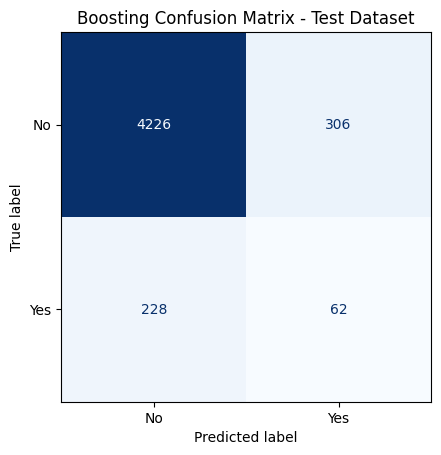

In [453]:
# Create a confusion matrix
cm = confusion_matrix(y_test, y_hat_test_dummy)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

# Customize plot
disp.plot(cmap='Blues', colorbar=False)
plt.title('Boosting Confusion Matrix - Test Dataset')

# Show plot
plt.show();

In [454]:
# Compute total 'Yes'
yes_total = cm[1].sum()
yes_correct = cm[1][1]

# 'Yes' pred that are correct in relative numbers
yes_correct_fraction_boosting = round((yes_correct / yes_total) * 100, 2)

# Print results
print(f"""
{yes_correct_fraction_boosting} % is the fraction of people predicted to make \
a purchase that actually make one.
""")


21.38 % is the fraction of people predicted to make a purchase that actually make one.



In [455]:
# Set up a k-fold cross-validation
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a KNN method
knn = KNN()

# Range of neighbors to test
n_neighbors = range(3, 10, 2)

# Set up a grid search
grid = skm.GridSearchCV(
    estimator=knn,
    param_grid={'n_neighbors':n_neighbors},
    scoring='recall',
    n_jobs=-1,
    cv=kfold
)

# Fit grid
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': range(3, 10, 2)}, scoring='recall')

In [456]:
# Save optimal model
knn_optimal = grid.best_estimator_

# Predict on test dataset
y_hat_test = knn_optimal.predict(X_test)
y_hat_probs = knn_optimal.predict_proba(X_test)[:, 1]

# Adapt probabilities
y_hat_binary = np.where(y_hat_probs > 0.2, 1, 0)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_hat_test)
cm_book = confusion_matrix(y_test, y_hat_binary)

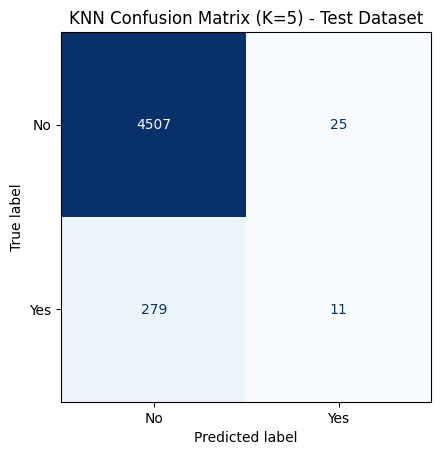

In [457]:
# Get n_neighbors
k = knn_optimal.n_neighbors

# Plot the confusion matrix
labels = sorted(['No', 'Yes'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

# Customize
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'KNN Confusion Matrix (K={k}) - Test Dataset');

In [458]:
# Compute 'yes' metrics
yes_correct = cm[1][1]
yes_total = cm[1].sum()
yes_correct_fraction_knn = round((yes_correct / yes_total)*100, 2)

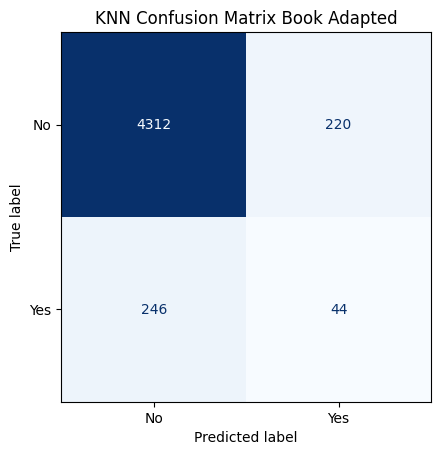

In [459]:
# Get n_neighbors
k = knn_optimal.n_neighbors

# Plot the confusion matrix
labels = sorted(['No', 'Yes'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_book,
    display_labels=labels
)

# Customize
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'KNN Confusion Matrix Book Adapted');

In [460]:
# Compute 'yes' metrics
yes_correct = cm_book[1][1]
yes_total = cm_book[1].sum()
yes_correct_fraction_knn_book = round((yes_correct / yes_total)*100, 2)

In [461]:
# Set up a logistic regression
logistic_reg = LogisticRegression(
    max_iter=1000,
    random_state=0
).fit(X_train, y_train)

# Predict on test dataset
y_hat_test = logistic_reg.predict(X_test)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_hat_test)

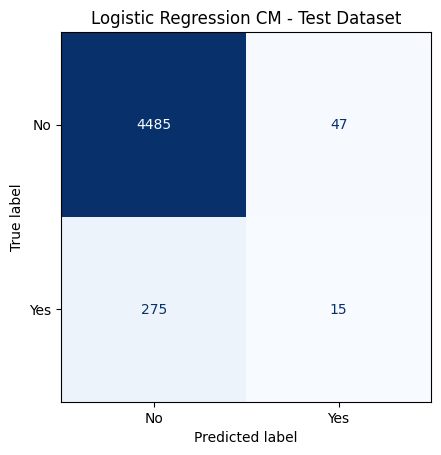

In [462]:
# Plot the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

# Customize
disp.plot(cmap='Blues', colorbar=False)
plt.title('Logistic Regression CM - Test Dataset');

In [463]:
# Compute 'yes' metrics
yes_correct = cm[1][1]
yes_total = cm[1].sum()
yes_correct_fraction_logistic = round((yes_correct / yes_total)*100, 2)

In [464]:
# Set up logist regression
glm = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()

# Predict on test dataset
y_hat_test = glm.predict(X_test)

# Adapt prediction to binary
y_hat_test_binary = y_hat_test.apply(lambda x: 1 if x >= 0.5 else 0)
y_hat_test_binary_book = y_hat_test.apply(lambda x: 1 if x > 0.2 else 0)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_hat_test_binary)
cm_book = confusion_matrix(y_test, y_hat_test_binary_book)

In [465]:
# Compute 'yes' metrics
yes_correct = cm_book[1][1]
yes_total = cm_book[1].sum()
yes_correct_fraction_logistic_book = np.round((yes_correct / yes_total)*100, 2)

In [466]:
# Print results
print(f"""
Correct 'Yes' Fraction
----------------------
Logistic:          \t {yes_correct_fraction_logistic}%
Logistic (adapted):\t {yes_correct_fraction_logistic_book}%
KNN:               \t {yes_correct_fraction_knn}%
KNN (adapted):     \t {yes_correct_fraction_knn_book}%
Boosting:          \t {yes_correct_fraction_boosting}%
""")


Correct 'Yes' Fraction
----------------------
Logistic:          	 5.17%
Logistic (adapted):	 21.03%
KNN:               	 3.79%
KNN (adapted):     	 15.17%
Boosting:          	 21.38%



No model achieves high accuracy in classifying purchases. The Boosting model's results appear inflated due to classifying any probability above 20% as a purchase. While this approach may be beneficial overall, it comes at the cost of increasing false positives (FP), which must be carefully considered.

Similarly, both Logistic Regression and KNN output inflated metrics when applying the same 20% probability threshold. However, only Logistic Regression achieves performance comparable to Boosting, whereas KNN delivers the weakest results.

---

### Question 12

In [486]:
# Load titanic survival dataset
titanic = pd.read_csv('data/titanic/train.csv')
titanic_test = pd.read_csv('data/titanic/test.csv')
titanic_template = pd.read_csv('data/titanic/gender_submission.csv')

# Adapt column names
titanic.columns = [x.lower() for x in titanic.columns]

In [487]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [488]:
# Check initial observations
titanic.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [489]:
# Removing initial columns
titanic_filtered = titanic.drop(columns=['passengerid', 'name']).copy()

# Check initial observations
titanic_filtered.head()

,survived,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [490]:
# Check possible values from a few features
columns = ['pclass', 'sibsp', 'parch', 'ticket', 'cabin', 'embarked']
for column in columns:
    print(f'\n{column}')
    print(list(set(titanic_filtered[column])))


pclass
[1, 2, 3]

sibsp
[0, 1, 2, 3, 4, 5, 8]

parch
[0, 1, 2, 3, 4, 5, 6]

ticket
['12233', '394140', '345777', '2680', 'STON/O 2. 3101294', '2926', '315151', 'PC 17612', '350417', '358585', 'C 7075', '19943', 'PC 17475', '250649', '330909', '370375', '2693', 'LINE', '113773', 'SOTON/O.Q. 3101311', 'W./C. 6607', 'PC 17611', '7553', '36973', 'SC/PARIS 2133', '350042', '3101265', '334912', '343275', '349223', 'A.5. 18509', '347067', '2627', '28425', '28424', 'PC 17608', '370369', '373450', 'C.A. 29395', '2223', 'PC 17473', '29750', 'C.A. 29178', 'SOTON/OQ 392089', '113760', '2694', '349256', '65306', '349225', 'C.A. 31026', '330935', 'A/5 2466', '3474', '349912', '236853', '240929', '347464', '113800', '113056', '323951', '350050', '2664', 'C.A. 2315', '12460', '349910', '13213', '29108', '330919', 'SOTON/O.Q. 3101310', '343095', 'S.C./A.4. 23567', '28213', '19947', '349206', '11765', '376564', '244252', '248706', 'PC 17604', '2624', 'PC 17318', '14313', 'S.C./PARIS 2079', 'C.A. 33111'

In [491]:
# Count possible values
for column in columns:
    print(f'')
    print(titanic_filtered[column].value_counts())


pclass
3    491
1    216
2    184
Name: count, dtype: int64

sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

ticket
1601         7
CA. 2343     7
347082       7
3101295      6
CA 2144      6
            ..
A/5 21172    1
349219       1
234818       1
345364       1
A/5 2466     1
Name: count, Length: 681, dtype: int64

cabin
B96 B98        4
G6             4
C23 C25 C27    4
F2             3
C22 C26        3
              ..
C106           1
A19            1
D7             1
C118           1
E50            1
Name: count, Length: 147, dtype: int64

embarked
S    644
C    168
Q     77
Name: count, dtype: int64


We should implement feature engineering to improve the value of certain features. For example, features with highly specific and sparse information should be grouped into broader categoriess to improve their predictive power.

Currently, 'ticket' does not provide clear useful information, so we will exclude it from the moddel.

The 'age' feature should be transformed to enhance its predictive power. Possible approaches include grouping it into distinct age categories (e.g., child, young adult, middle-aged, senior) or applying a non-linear transformation, such as squaring, to capture non-linear relationships.

The 'cabin' feature contains many missing values and sparse information. A better approach would be to either convert it into a binary indicator (e.g. whether a cabin is assigned or not) or extract the cabin letter (e.g., 'C') to retain its main distinction.

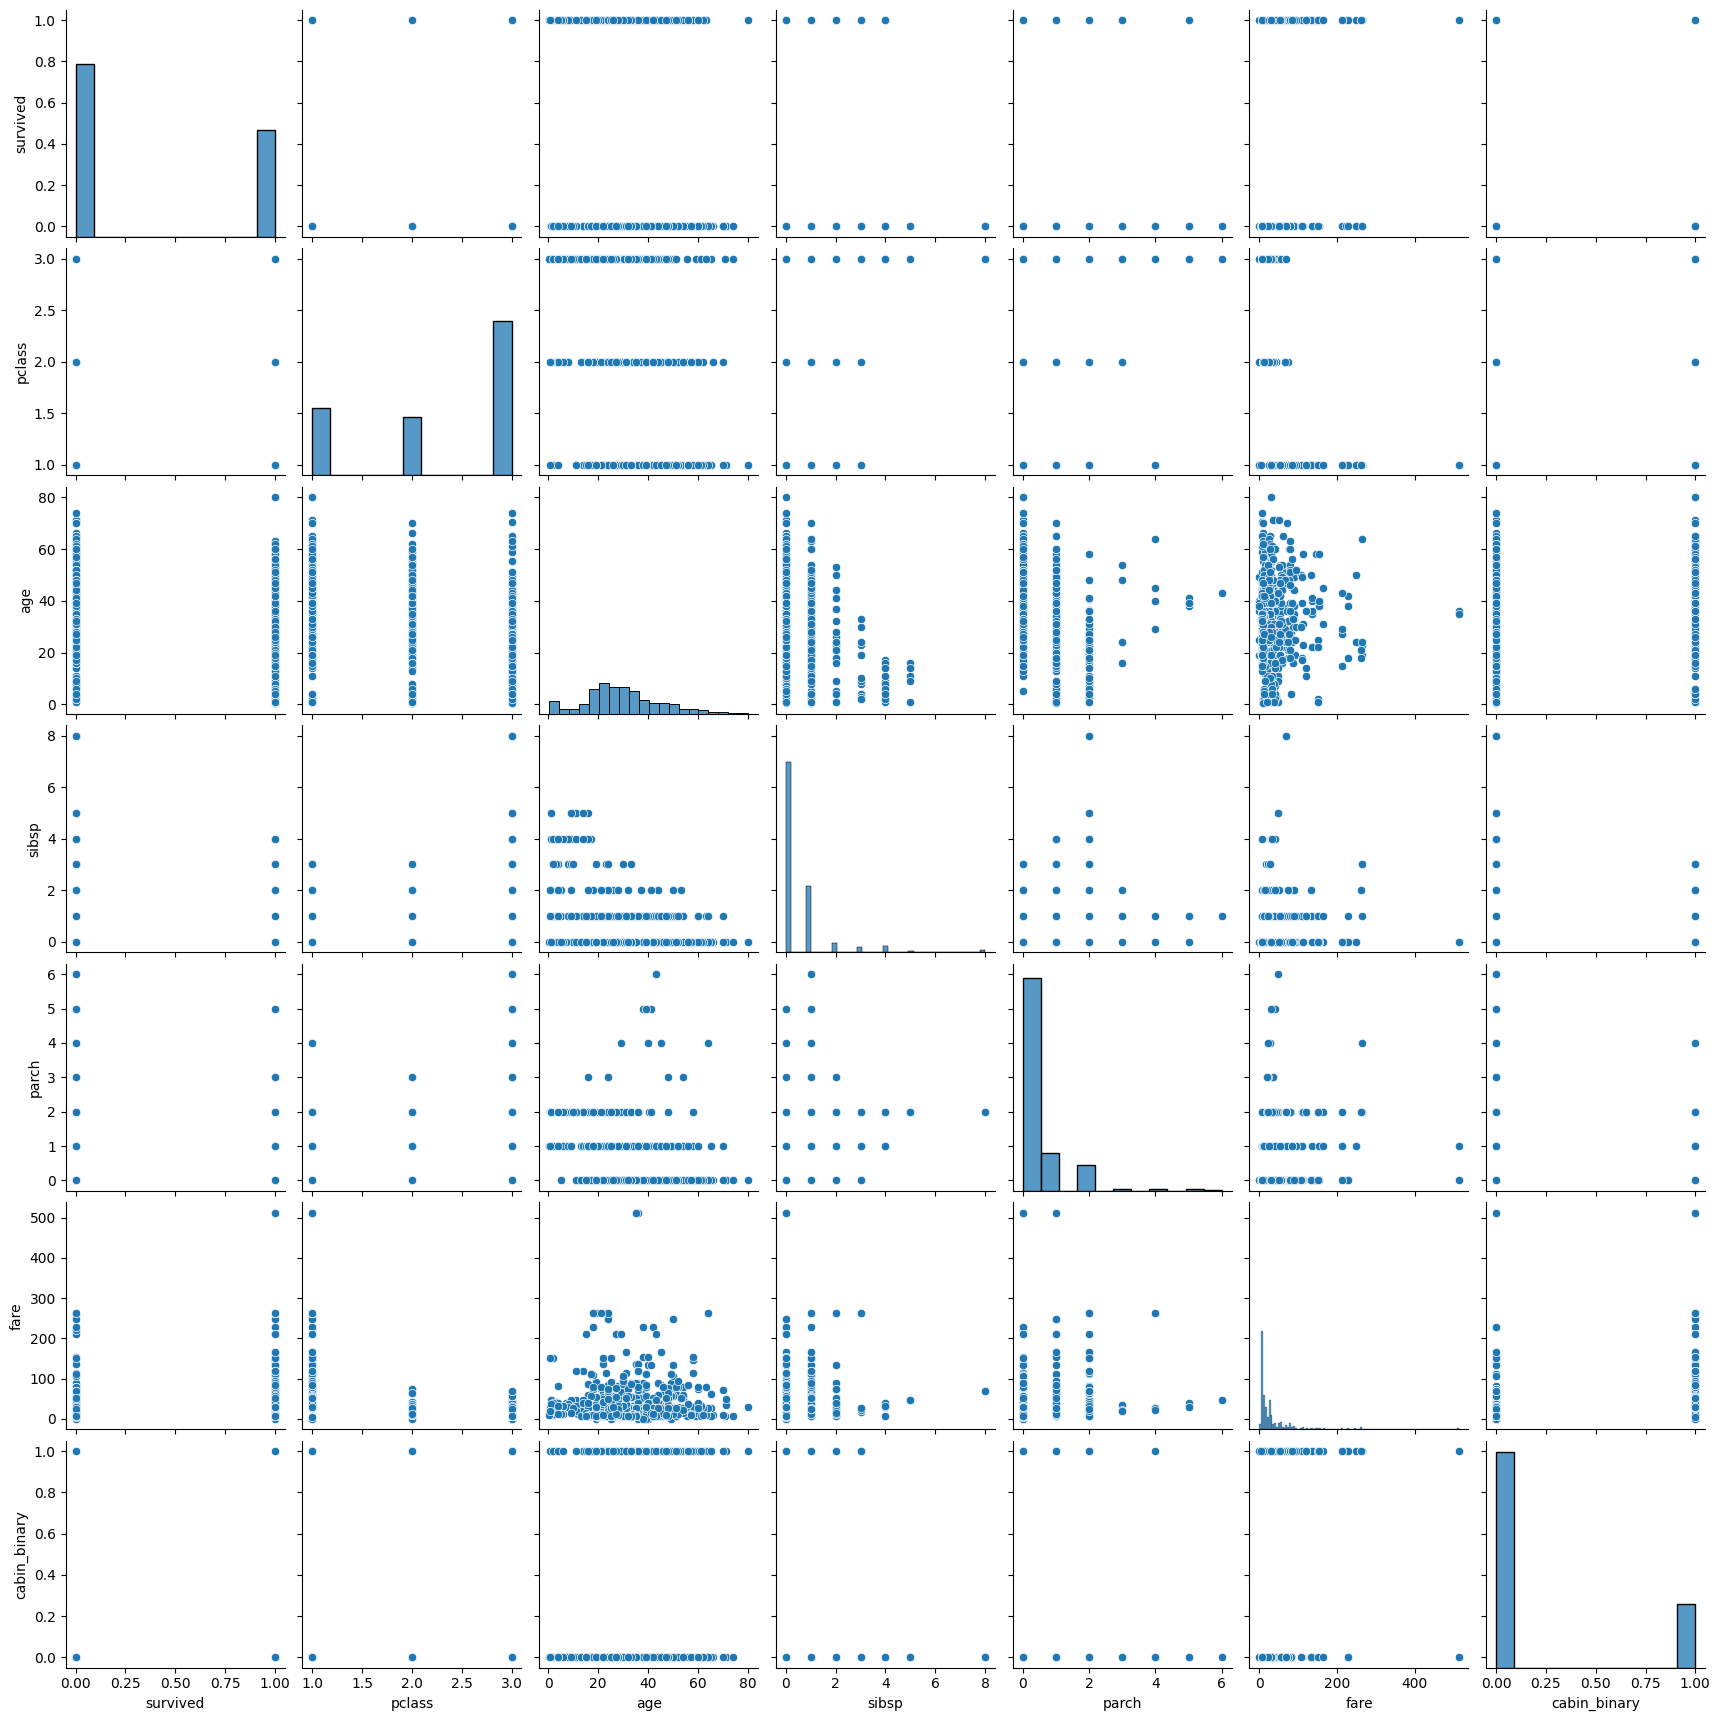

In [509]:
# Show a pairplot of the data
sns.pairplot(titanic_filtered);

The plot above provides valuable insights through visualization. For example, when examining the relationship between 'fare' and 'survived', there seems to be outliers who survived with very high 'fare' values. This could significantly influence a linear model like Logistic Regression, potentially leading it to overestimate a relationship between 'fare' and 'survived'.

In [537]:
# Investigate 'fare'
titanic_filtered['fare'].describe()

count    889.000000
mean      32.096681
std       49.697504
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

In [538]:
# Show top 'fare' values
sorted(titanic_filtered['fare'], reverse=True)[:10]

[512.3292,
 512.3292,
 512.3292,
 263.0,
 263.0,
 263.0,
 263.0,
 262.375,
 262.375,
 247.5208]

In [539]:
# Get average 'fare' for 'survived'=1
fare_avg_survived = titanic_filtered[
    titanic_filtered['survived']==1
]['fare'].mean()

# Get average 'fare' for 'survived'=0
fare_avg_notsurvived = titanic_filtered[
    titanic_filtered['survived']==0
]['fare'].mean()

# Print findings
print(f"""
Fare Average per Group
----------------------
fare_avg_survived:    \t{round(fare_avg_survived, 2)}
fare_avg_notsurvived: \t{round(fare_avg_notsurvived, 2)}
""")


Fare Average per Group
----------------------
fare_avg_survived:    	48.21
fare_avg_notsurvived: 	22.12



In [557]:
# Start creating the train/test dataset
titanic_dataset = titanic_filtered.copy()

# Remove very high'fare' values
titanic_dataset = titanic_dataset[titanic_dataset['fare']<500]

# Drop feature 'ticket'
titanic_dataset.drop(columns='ticket', inplace=True)

# Create a function to adapt 'cabin'
def cabin_adaptation(value):
    if pd.notna(value):
        return value.strip()[0]
    else:
        return 'NA'

# Adapt 'cabin'
titanic_dataset['cabin_cat'] = titanic_dataset['cabin'].apply(cabin_adaptation)
titanic_dataset['cabin_binary'] = titanic_dataset['cabin'].apply(
    lambda x: 1 if pd.notna(x) else 0
)

# Drop original 'cabin'
titanic_dataset.drop(columns='cabin', inplace=True)

# Get the median 'age' to replace missing values
age_median = titanic_dataset['age'].median()
titanic_dataset['age'] = titanic_dataset['age'].fillna(age_median)

# Add 'age' squared
age2 = np.square(titanic_dataset['age'])
titanic_dataset.insert(4, 'age2', age2)

# Transform categoricals into dummies
titanic_dataset = pd.get_dummies(titanic_dataset, drop_first=True, dtype='int')

In [558]:
titanic_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 886 entries, 0 to 890
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   survived      886 non-null    int64  
 1   pclass        886 non-null    int64  
 2   age           886 non-null    float64
 3   age2          886 non-null    float64
 4   sibsp         886 non-null    int64  
 5   parch         886 non-null    int64  
 6   fare          886 non-null    float64
 7   cabin_binary  886 non-null    int64  
 8   sex_male      886 non-null    int64  
 9   embarked_Q    886 non-null    int64  
 10  embarked_S    886 non-null    int64  
 11  cabin_cat_B   886 non-null    int64  
 12  cabin_cat_C   886 non-null    int64  
 13  cabin_cat_D   886 non-null    int64  
 14  cabin_cat_E   886 non-null    int64  
 15  cabin_cat_F   886 non-null    int64  
 16  cabin_cat_G   886 non-null    int64  
 17  cabin_cat_NA  886 non-null    int64  
 18  cabin_cat_T   886 non-null    int64

In [572]:
# Split into 'X' and 'y'
X = titanic_dataset.drop(columns='survived').copy()
y = titanic_dataset['survived']

# Generate train & test dataframes
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, 
    y, 
    random_state=0, 
    shuffle=True
)

# Split different 'cabin' feature methods
columns_cabin_binary = X.columns[:10]
columns_cabin_cat = [col for col in X.columns if col != 'cabin_binary']

# Filter 'X_train' & 'X_test'
X_train_cabin_binary = X_train[columns_cabin_binary]
X_test_cabin_binary = X_test[columns_cabin_binary]
X_train_cabin_cat = X_train[columns_cabin_cat]
X_test_cabin_cat = X_test[columns_cabin_cat]

In [651]:
# Create a dataframe to hold the results
results_df = pd.DataFrame(columns=['Model', 'Test Accuracy'])

# Parameters to test
lr_list = np.logspace(-1, -4, 25)
max_depth_list = [2, 3, 4, 5]

# Parameters fixed
n_estimators=1000

# Set up a model
boosting = GBC(n_estimators=n_estimators, random_state=0)

# Set up a param grid
param_grid = {
    'learning_rate': lr_list,
    'max_depth': max_depth_list
}

# Set up k-fold cross-validation
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a grid search
grid_cabin_binary = skm.GridSearchCV(
    estimator=boosting,
    scoring='accuracy', #'accuracy', 'f1', ''neg_log_loss', 'recall'
    param_grid=param_grid,
    n_jobs=-1,
    cv=kfold    
)

grid_cabin_cat = skm.GridSearchCV(
    estimator=boosting,
    scoring='accuracy', #'accuracy', 'f1', ''neg_log_loss', 'recall'
    param_grid=param_grid,
    n_jobs=-1,
    cv=kfold    
)

# Fit
results_cabin_binary = grid_cabin_binary.fit(X_train_cabin_binary, y_train)
results_cabin_cat = grid_cabin_cat.fit(X_train_cabin_cat, y_train)

In [652]:
# Select best model
model_boosting_cabin_binary = results_cabin_binary.best_estimator_

# Show results
results_cabin_binary

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=GradientBoostingClassifier(n_estimators=1000,
                                                  random_state=0),
             n_jobs=-1,
             param_grid={'learning_rate': array([1.00000000e-01, 7.49894209e-02, 5.62341325e-02, 4.21696503e-02,
       3.16227766e-02, 2.37137371e-02, 1.77827941e-02, 1.33352143e-02,
       1.00000000e-02, 7.49894209e-03, 5.62341325e-03, 4.21696503e-03,
       3.16227766e-03, 2.37137371e-03, 1.77827941e-03, 1.33352143e-03,
       1.00000000e-03, 7.49894209e-04, 5.62341325e-04, 4.21696503e-04,
       3.16227766e-04, 2.37137371e-04, 1.77827941e-04, 1.33352143e-04,
       1.00000000e-04]),
                         'max_depth': [2, 3, 4, 5]},
             scoring='accuracy')

In [653]:
# Select best model
model_boosting_cabin_cat = results_cabin_cat.best_estimator_

# Show results
results_cabin_cat

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=GradientBoostingClassifier(n_estimators=1000,
                                                  random_state=0),
             n_jobs=-1,
             param_grid={'learning_rate': array([1.00000000e-01, 7.49894209e-02, 5.62341325e-02, 4.21696503e-02,
       3.16227766e-02, 2.37137371e-02, 1.77827941e-02, 1.33352143e-02,
       1.00000000e-02, 7.49894209e-03, 5.62341325e-03, 4.21696503e-03,
       3.16227766e-03, 2.37137371e-03, 1.77827941e-03, 1.33352143e-03,
       1.00000000e-03, 7.49894209e-04, 5.62341325e-04, 4.21696503e-04,
       3.16227766e-04, 2.37137371e-04, 1.77827941e-04, 1.33352143e-04,
       1.00000000e-04]),
                         'max_depth': [2, 3, 4, 5]},
             scoring='accuracy')

In [701]:
# Get train accuracy from each approach
y_hat_cabin_binary = model_boosting_cabin_binary.predict(X_test_cabin_binary)
y_hat_cabin_cat = model_boosting_cabin_cat.predict(X_test_cabin_cat)

# Create confusion matrix
cm_cabin_binary = confusion_matrix(y_test, y_hat_cabin_binary)
cm_cabin_cat = confusion_matrix(y_test, y_hat_cabin_cat)

# Accuracy
acc_cabin_binary = accuracy_score(y_test, y_hat_cabin_binary)
acc_cabin_cat = accuracy_score(y_test, y_hat_cabin_cat)

# Update results_df
results_df.loc[len(results_df)] = 'Boosting Cabin Binary', acc_cabin_binary
results_df.loc[len(results_df)] = 'Boosting Cabin Cat', acc_cabin_cat

# Show cm
print(f"""
Boosting Cabin Binary
---------------------
{cm_cabin_binary}

acc_cabin_binary: {round(acc_cabin_binary * 100, 2)}
""")
print(f"""
Boosting Cabin Cat
------------------
{cm_cabin_cat}

acc_cabin_cat: {round(acc_cabin_cat * 100, 2)}
""")


Boosting Cabin Binary
---------------------
[[130  10]
 [ 25  57]]

acc_cabin_binary: 84.23


Boosting Cabin Cat
------------------
[[130  10]
 [ 25  57]]

acc_cabin_cat: 84.23



In [656]:
#%% RANDOM FOREST - BINARY DATASET

# Parameters to test
max_depth_list = [2, 3, 4, 5, 6]
criterion_list = ['gini', 'entropy', 'log_loss']
max_features = X_train_cabin_binary.shape[1]

# Parameters fixed
n_estimators=1000

# Set up a model
bagging = RFC(n_estimators=n_estimators, random_state=0, n_jobs=-1)

# Set up a param grid
param_grid = {
    'criterion': criterion_list,
    'max_depth': max_depth_list
}

# Set up k-fold cross-validation
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a grid search
grid_cabin_binary = skm.GridSearchCV(
    estimator=bagging,
    scoring='accuracy', #'accuracy', 'f1', ''neg_log_loss', 'recall'
    param_grid=param_grid,
    n_jobs=-1,
    cv=kfold    
)

# Fit
results_cabin_binary = grid_cabin_binary.fit(X_train_cabin_binary, y_train)

In [657]:
# Save best model
model_bagging_cabin_binary = results_cabin_binary.best_estimator_

# Track best parameters
criterion_cabin_binary = model_bagging_cabin_binary.criterion
max_depth_cabin_binary = model_bagging_cabin_binary.max_depth

# Show best model
model_bagging_cabin_binary

RandomForestClassifier(max_depth=5, n_estimators=1000, n_jobs=-1,
                       random_state=0)

In [658]:
#%% RANDOM FOREST - CAT DATASET

# Parameters to test
max_depth_list = [2, 3, 4, 5, 6]
criterion_list = ['gini', 'entropy', 'log_loss']
max_features = X_train_cabin_cat.shape[1]

# Parameters fixed
n_estimators=1000

# Set up a model
bagging = RFC(n_estimators=n_estimators, random_state=0, n_jobs=-1)

# Set up a param grid
param_grid = {
    'criterion': criterion_list,
    'max_depth': max_depth_list
}

# Set up k-fold cross-validation
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a grid search
grid_cabin_cat = skm.GridSearchCV(
    estimator=bagging,
    scoring='accuracy', #'accuracy', 'f1', ''neg_log_loss', 'recall'
    param_grid=param_grid,
    n_jobs=-1,
    cv=kfold    
)

# Fit
results_cabin_cat = grid_cabin_cat.fit(X_train_cabin_cat, y_train)

In [659]:
# Save best model
model_bagging_cabin_cat = results_cabin_cat.best_estimator_

# Track best parameters
criterion_cabin_cat = model_bagging_cabin_cat.criterion
max_depth_cabin_cat = model_bagging_cabin_cat.max_depth

# Show best model
model_bagging_cabin_cat

RandomForestClassifier(criterion='entropy', max_depth=5, n_estimators=1000,
                       n_jobs=-1, random_state=0)

In [660]:
# Print best optimal parameters
print(f"""
Bagging Params - 'cabin_binary'
-------------------------------
criterion: {criterion_cabin_cat}
max_depth: {max_depth_cabin_cat}
""")

print(f"""
Bagging Params - 'cabin_cat'
-------------------------------
criterion: {criterion_cabin_cat}
max_depth: {max_depth_cabin_cat}
""")


Bagging Params - 'cabin_binary'
-------------------------------
criterion: entropy
max_depth: 5


Bagging Params - 'cabin_cat'
-------------------------------
criterion: entropy
max_depth: 5



In [702]:
# Get train accuracy from each approach
y_hat_cabin_binary = model_bagging_cabin_binary.predict(X_test_cabin_binary)
y_hat_cabin_cat = model_bagging_cabin_cat.predict(X_test_cabin_cat)

# Create confusion matrix
cm_cabin_binary = confusion_matrix(y_test, y_hat_cabin_binary)
cm_cabin_cat = confusion_matrix(y_test, y_hat_cabin_cat)

# Accuracy
acc_cabin_binary = accuracy_score(y_test, y_hat_cabin_binary)
acc_cabin_cat = accuracy_score(y_test, y_hat_cabin_cat)

# Update results_df
results_df.loc[len(results_df)] = 'Bagging Cabin Binary', acc_cabin_binary
results_df.loc[len(results_df)] = 'Bagging Cabin Cat', acc_cabin_cat

# Show cm
print(f"""
Bagging Cabin Binary
--------------------
{cm_cabin_binary}

acc_cabin_binary: {round(acc_cabin_binary * 100, 2)}
""")
print(f"""
Bagging Cabin Cat
-----------------
{cm_cabin_cat}

acc_cabin_cat: {round(acc_cabin_cat * 100, 2)}
""")


Bagging Cabin Binary
--------------------
[[132   8]
 [ 26  56]]

acc_cabin_binary: 84.68


Bagging Cabin Cat
-----------------
[[132   8]
 [ 27  55]]

acc_cabin_cat: 84.23



In [662]:
#%% RANDOM FOREST - CAT DATASET

# Features size
features_size = X_train_cabin_cat.shape[1]

# Create max features to test
features_half = int(features_size / 2)
features_sqrt = int(np.sqrt(features_size))

# Parameters to testS
max_depth_list = [2, 3, 4, 5, 6]
criterion_list = ['gini', 'entropy', 'log_loss']
max_features = [features_half, features_sqrt]

# Parameters fixed
n_estimators=1000

# Set up a model
rf = RFC(n_estimators=n_estimators, random_state=0, n_jobs=-1)

# Set up a param grid
param_grid = {
    'criterion': criterion_list,
    'max_depth': max_depth_list,
    'max_features': max_features
}

# Set up k-fold cross-validation
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a grid search
rf_cabin_cat = skm.GridSearchCV(
    estimator=rf,
    scoring='accuracy', #'accuracy', 'f1', ''neg_log_loss', 'recall'
    param_grid=param_grid,
    n_jobs=-1,
    cv=kfold    
)

# Fit
results_cabin_cat = rf_cabin_cat.fit(X_train_cabin_cat, y_train)

In [663]:
# Save the best model
model_rf_cabin_cat = results_cabin_cat.best_estimator_

# Get optimal parameters
criterion_tf_cabin_cat = model_rf_cabin_cat.criterion
max_depth_tf_cabin_cat = model_rf_cabin_cat.max_depth
max_features_tf_cabin_cat = model_rf_cabin_cat.max_features

# Show best model
model_rf_cabin_cat

RandomForestClassifier(criterion='entropy', max_depth=5, max_features=4,
                       n_estimators=1000, n_jobs=-1, random_state=0)

In [670]:
#%% RANDOM FOREST - BINARY DATASET

# Features size
features_size = X_train_cabin_binary.shape[1]

# Create max features to test
features_half = int(features_size / 2)
features_sqrt = int(np.sqrt(features_size))

# Parameters to testS
max_depth_list = [2, 3, 4, 5, 6]
criterion_list = ['gini', 'entropy', 'log_loss']
max_features = [features_half, features_sqrt]

# Parameters fixed
n_estimators=1000

# Set up a model
rf = RFC(n_estimators=n_estimators, random_state=0, n_jobs=-1)

# Set up a param grid
param_grid = {
    'criterion': criterion_list,
    'max_depth': max_depth_list,
    'max_features': max_features
}

# Set up k-fold cross-validation
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Set up a grid search
rf_cabin_binary = skm.GridSearchCV(
    estimator=rf,
    scoring='accuracy', #'accuracy', 'f1', ''neg_log_loss', 'recall'
    param_grid=param_grid,
    n_jobs=-1,
    cv=kfold    
)

# Fit
results_cabin_binary = rf_cabin_binary.fit(X_train_cabin_binary, y_train)

In [672]:
# Get the bet model
model_rf_cabin_binary = results_cabin_binary.best_estimator_

# Get optimal parameters
criterion_tf_cabin_binary = model_rf_cabin_binary.criterion
max_depth_tf_cabin_binary = model_rf_cabin_binary.max_depth
max_features_tf_cabin_binary = model_rf_cabin_binary.max_features

# Show best model
model_rf_cabin_binary

RandomForestClassifier(max_depth=5, max_features=3, n_estimators=1000,
                       n_jobs=-1, random_state=0)

In [703]:
# Predict on test dataset
y_hat_cabin_binary = model_rf_cabin_binary.predict(X_test_cabin_binary)
y_hat_cabin_cat = model_rf_cabin_cat.predict(X_test_cabin_cat)

# Create a confusion matrix
cm_cabin_binary = confusion_matrix(y_test, y_hat_cabin_binary)
cm_cabin_cat = confusion_matrix(y_test, y_hat_cabin_cat)

# Compute accuracy
acc_cabin_binary = accuracy_score(y_test, y_hat_cabin_binary)
acc_cabin_cat = accuracy_score(y_test, y_hat_cabin_cat)

# Update dataframe
results_df.loc[len(results_df)] = 'RF Cabin Binary', acc_cabin_binary
results_df.loc[len(results_df)] = 'RF Cabin Cat', acc_cabin_cat


# Print
print(f"""
RF Cabin Binary
---------------
{cm_cabin_binary}

acc_cabin_binary: {round(acc_cabin_binary * 100, 2)}
""")

print(f"""
RF Cabin Cat
------------
{cm_cabin_cat}

acc_cabin_cat: {round(acc_cabin_cat * 100, 2)}
""")


RF Cabin Binary
---------------
[[132   8]
 [ 26  56]]

acc_cabin_binary: 84.68


RF Cabin Cat
------------
[[132   8]
 [ 27  55]]

acc_cabin_cat: 84.23



In [704]:
# Set up the logistic regression model
lr_cabin_binary = LogisticRegression(max_iter=3000)
lr_cabin_cat = LogisticRegression(max_iter=3000)

# Fit
lr_cabin_binary.fit(X_train_cabin_binary, y_train)
lr_cabin_cat.fit(X_train_cabin_cat, y_train)

# Predict on test dataset
y_hat_cabin_binary = lr_cabin_binary.predict(X_test_cabin_binary)
y_hat_cabin_cat = lr_cabin_cat.predict(X_test_cabin_cat)

# Create CM
cm_cabin_binary = confusion_matrix(y_test, y_hat_cabin_binary)
cm_cabin_cat = confusion_matrix(y_test, y_hat_cabin_cat)

# Compute accuracy
acc_cabin_binary = accuracy_score(y_test, y_hat_cabin_binary)
acc_cabin_cat = accuracy_score(y_test, y_hat_cabin_cat)

# Update results_df
results_df.loc[len(results_df)] = 'Logistic Cabin Binary', acc_cabin_binary
results_df.loc[len(results_df)] = 'Logistic Cabin Cat', acc_cabin_cat

In [705]:
# Print
print(f"""
Logistic Cabin Binary
---------------------
{cm_cabin_binary}

acc_cabin_binary: {round(acc_cabin_binary * 100, 2)}
""")

print(f"""
Logistic Cabin Cat
------------------
{cm_cabin_cat}

acc_cabin_cat: {round(acc_cabin_cat * 100, 2)}
""")


Logistic Cabin Binary
---------------------
[[125  15]
 [ 16  66]]

acc_cabin_binary: 86.04


Logistic Cabin Cat
------------------
[[127  13]
 [ 18  64]]

acc_cabin_cat: 86.04



In [706]:
# Show results
results_df.style.hide(axis='index')

Model,Test Accuracy
Boosting Cabin Binary,0.842342
Boosting Cabin Cat,0.842342
Bagging Cabin Binary,0.846847
Bagging Cabin Cat,0.842342
RF Cabin Binary,0.846847
RF Cabin Cat,0.842342
Logistic Cabin Binary,0.860360
Logistic Cabin Cat,0.860360


Overall, the tree-based models exhibit comparable accuracy on the test dataset, even when applying different feature engineering strategies to the 'cabin' feature.

However, despite these refinements, Logistic Regression ultimately delivers the highest accuracy on the test dataset among all models.